### Performing CHI-SQUARE for feature Selection

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titenic=df[["pclass","sex","sibsp","parch","embarked","survived"]]
titenic.head()

,pclass,sex,sibsp,parch,embarked,survived
0,3,male,1,0,S,0
1,1,female,1,0,C,1
2,3,female,0,0,S,1
3,1,female,1,0,S,1
4,3,male,0,0,S,0


In [6]:
### Sex important for surviced or not
# for that first we maek contigency table
contingency_table = pd.crosstab(titenic['sex'], titenic['survived'])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [8]:
ct=pd.crosstab(titenic['sex'], titenic['survived'],margins=True)
ct

survived,0,1,All
sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


In [10]:
from scipy.stats import chi2_contingency
chi2_contingency(ct)

Chi2ContingencyResult(statistic=np.float64(263.05057407065567), pvalue=np.float64(1.0036732821369115e-55), dof=4, expected_freq=array([[193.47474747, 120.52525253, 314.        ],
       [355.52525253, 221.47474747, 577.        ],
       [549.        , 342.        , 891.        ]]))

In [11]:
score=[]
for feture in titenic.columns[:-1]:
    ct=pd.crosstab(titenic[feture], titenic['survived'],margins=True)
    pvalue=chi2_contingency(ct)[1]
    score.append(pvalue)

In [12]:
score

[np.float64(6.258462423531468e-20),
 np.float64(1.0036732821369115e-55),
 np.float64(0.000670965497493342),
 np.float64(0.014554047586837711),
 np.float64(0.00018045058101554055)]

<Axes: >

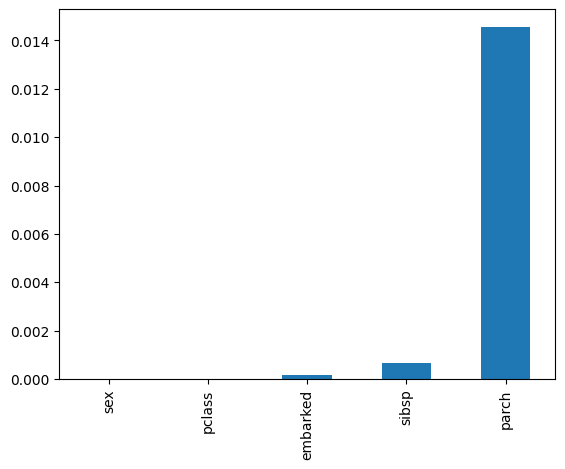

In [13]:
pd.Series(score,index=titenic.columns[:-1]).sort_values(ascending=True).plot.bar()